In [ ]:
#mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#extracting the exacat file  path of the selected dataset
!find '/content/drive/MyDrive' -name 'goemotions.csv'

/content/drive/MyDrive/Data science /goemotions.csv


#Dataset Overview

In [ ]:
#loading the dataset
import pandas as pd
path= '/content/drive/MyDrive/Data science /goemotions.csv'
df=pd.read_csv(path)

In [ ]:
df

,text,id,author,subreddit,link_id,parent_id,created_utc,rater_id,example_very_unclear,admiration,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,That game hurt.,eew5j0j,Brdd9,nrl,t3_ajis4z,t1_eew18eq,1.548381e+09,1,False,0,...,0,0,0,0,0,0,0,1,0,0
1,>sexuality shouldn’t be a grouping category I...,eemcysk,TheGreen888,unpopularopinion,t3_ai4q37,t3_ai4q37,1.548084e+09,37,True,0,...,0,0,0,0,0,0,0,0,0,0
2,"You do right, if you don't care then fuck 'em!",ed2mah1,Labalool,confessions,t3_abru74,t1_ed2m7g7,1.546428e+09,37,False,0,...,0,0,0,0,0,0,0,0,0,1
3,Man I love reddit.,eeibobj,MrsRobertshaw,facepalm,t3_ahulml,t3_ahulml,1.547965e+09,18,False,0,...,1,0,0,0,0,0,0,0,0,0
4,"[NAME] was nowhere near them, he was by the Fa...",eda6yn6,American_Fascist713,starwarsspeculation,t3_ackt2f,t1_eda65q2,1.546669e+09,2,False,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211220,Everyone likes [NAME].,ee6pagw,Senshado,heroesofthestorm,t3_agjf24,t3_agjf24,1.547634e+09,16,False,0,...,1,0,0,0,0,0,0,0,0,0
211221,Well when you’ve imported about a gazillion of...,ef28nod,5inchloser,nottheonion,t3_ak26t3,t3_ak26t3,1.548553e+09,15,False,0,...,0,0,0,0,0,0,0,0,0,0
211222,That looks amazing,ee8hse1,springt1me,shittyfoodporn,t3_agrnqb,t3_agrnqb,1.547684e+09,70,False,1,...,0,0,0,0,0,0,0,0,0,0
211223,The FDA has plenty to criticize. But like here...,edrhoxh,enamedata,medicine,t3_aejqzd,t1_edrgdtx,1.547169e+09,4,False,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
#summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211225 entries, 0 to 211224
Data columns (total 37 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   text                  211225 non-null  object 
 1   id                    211225 non-null  object 
 2   author                211225 non-null  object 
 3   subreddit             211225 non-null  object 
 4   link_id               211225 non-null  object 
 5   parent_id             211225 non-null  object 
 6   created_utc           211225 non-null  float64
 7   rater_id              211225 non-null  int64  
 8   example_very_unclear  211225 non-null  bool   
 9   admiration            211225 non-null  int64  
 10  amusement             211225 non-null  int64  
 11  anger                 211225 non-null  int64  
 12  annoyance             211225 non-null  int64  
 13  approval              211225 non-null  int64  
 14  caring                211225 non-null  int64  
 15  

In [ ]:
#getting the column names
df.columns

Index(['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id',
       'created_utc', 'rater_id', 'example_very_unclear', 'admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral'],
      dtype='object')

In [ ]:
#separating the emotion columns only
emotion_cols=['admiration',
       'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion',
       'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust',
       'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy',
       'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
       'remorse', 'sadness', 'surprise', 'neutral']

In [ ]:
#checking the dataset: is single labeled / multiple labeled
df['emotions_count']=df[emotion_cols].sum(axis=1)
df['emotions_count'].value_counts().sort_index()

,count
emotions_count,
0,3411
1,171820
2,31187
3,4218
4,399
5,106
6,53
7,20
8,6


moving forward by extracting only the single lable records only.

In [ ]:
  #extracting only the single label emotional contexts from the dataset

#removing rows without any emotions
df=df[df['emotions_count']>0].copy()

#removing rows where  annotators said it's very unclear
df=df[df['example_very_unclear']==False].copy()

print('shape of new dataset',df.shape)
print('\ntotal emotion count from the existing records')
df['emotions_count'].value_counts().sort_index()

shape of new dataset (207814, 38)

total emotion count from the existing records


,count
emotions_count,
1,171820
2,31187
3,4218
4,399
5,106
6,53
7,20
8,6
9,3


In [ ]:
#creating a single label from multi-label emotions
df['label']=df[emotion_cols].idxmax(axis=1) #here we are selecting the first emotion label with 1

#quick look
df[['text', 'label']].head(10)

,text,label
0,That game hurt.,sadness
2,"You do right, if you don't care then fuck 'em!",neutral
3,Man I love reddit.,love
4,"[NAME] was nowhere near them, he was by the Fa...",neutral
5,Right? Considering it’s such an important docu...,gratitude
6,"He isn't as big, but he's still quite popular....",disapproval
7,That's crazy; I went to a super [RELIGION] hig...,amusement
8,that's adorable asf,amusement
9,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin...",amusement
10,"I have, and now that you mention it, I think t...",neutral


In [ ]:
#baseline prediction
most_common=df['label'].value_counts().idxmax()
baseline_acc=(df['label']==most_common).mean()
print('baseline accuracy:',baseline_acc)


baseline accuracy: 0.26609371842128055


label
neutral           55298
admiration        17131
approval          15530
annoyance         11929
disapproval        8917
amusement          8862
gratitude          8437
anger              7956
curiosity          7707
disappointment     6769
confusion          6600
love               5310
caring             5147
realization        5125
joy                5120
optimism           4994
excitement         4375
sadness            3863
surprise           3472
disgust            3420
desire             3002
fear               2514
embarrassment      1720
remorse            1648
nervousness         946
relief              814
pride               714
grief               494
Name: count, dtype: int64


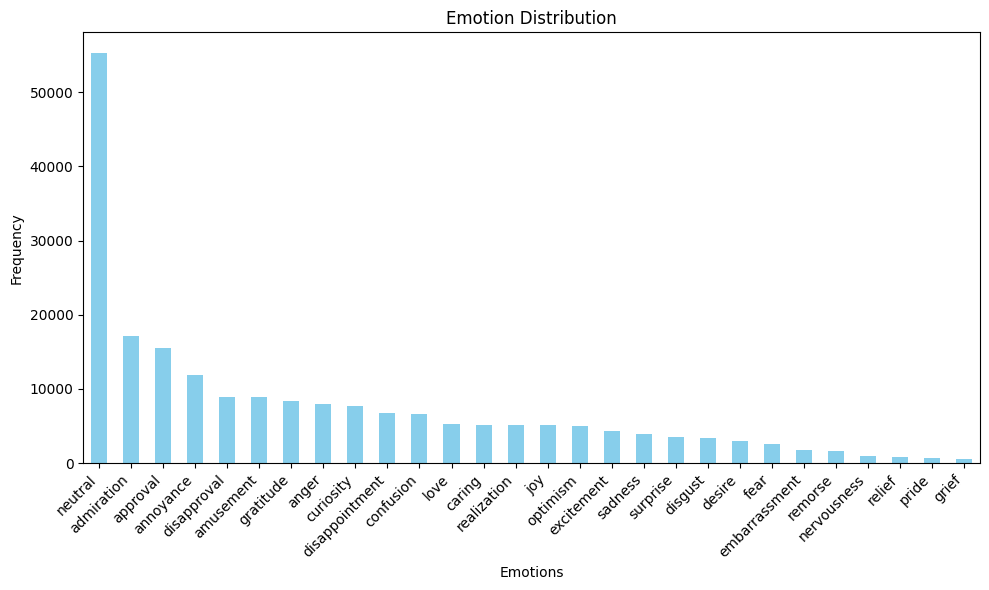

In [ ]:
#emotion distribution plot
import matplotlib.pyplot as plt


#counting frequency for each emotions
label_counts=df['label'].value_counts().sort_values(ascending=False)
print(label_counts)

#plotting
plt.figure(figsize=(10,6))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Emotion Distribution')
plt.xlabel('Emotions')
plt.ylabel('Frequency')
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

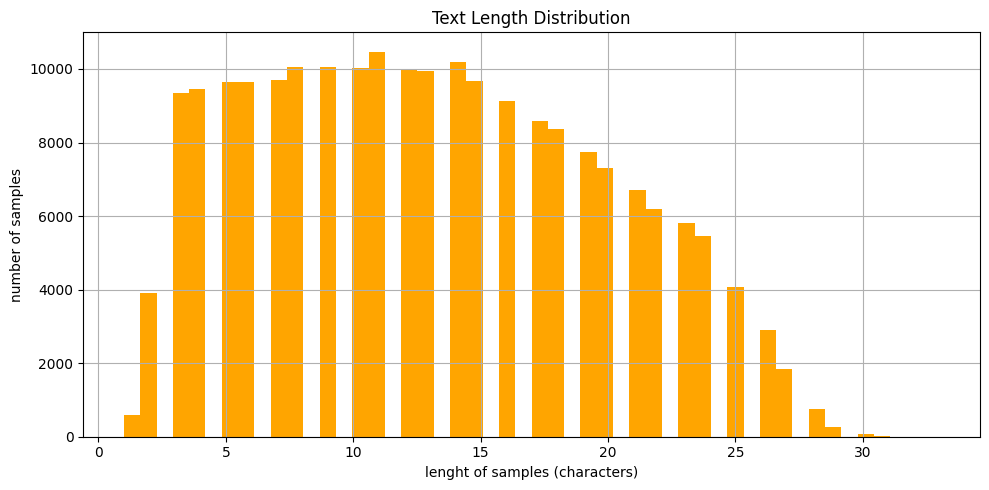

,text_length
count,207814.000000
mean,13.022703
std,6.666301
min,1.000000
25%,7.000000
50%,13.000000
75%,18.000000
max,33.000000


In [ ]:
#text length visualisation
df['text_length']=df['text'].apply(lambda x: len(str(x).split()))

#plotting
plt.figure(figsize=(10,5))
df['text_length'].hist(bins=50,color='orange')
plt.title('Text Length Distribution')
plt.xlabel('lenght of samples (characters)')
plt.ylabel('number of samples')
plt.tight_layout()

plt.show()

#descriptive summary
df['text_length'].describe()

#Pre Processing

In [ ]:
#installing necessary libraries
!pip install spacy contractions -q
!python -m spacy download en_core_web_sm -q

import spacy
import contractions
import re

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
nlp=spacy.load('en_core_web_sm')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 113.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#defining common slangs/ short words
slang_dict={
    "idk": "i do not know",
    "ikr": "i know right",
    "tbh": "to be honest",
    "smh": "shaking my head",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "btw": "by the way",
    "wbu": "what about you",
    "wbu?": "what about you",
    "wtf": " what the fuck",
    "wth": "what the hell",
    "fyi": "for your information",
    "lmao": "laughing my ass off",
    "loml": "love of my life",
    "brb": "be right back",
    "rn": "right now",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "ily": "i love you",
    "ty": "thank you",
    "tyvm": "thank you very much",
    "tysm": "thank you so much",
    "tyt": "take your time",
    "ttyl": "talk to you later",
    "rn": "right now",
    "fml": "fuck my life",
    "asf" : "as fuck"


}

#slang replacement function
def replace_slang(text: str) -> str:
  for word, replacement in slang_dict.items():
    text= re.sub(rf"\b{word}\b", replacement, text, flags=re.IGNORECASE )

  return text

In [ ]:
#defining swear words
swear_words= [
    "fuck", "fucking", "shit", "bitch", "bastard", "dick",
    "asshole", "crap", "damn", "wtf"]

swear_pattern=r'\b('+'|'.join(swear_words)+r')\b'

In [ ]:
#creating the preprocessing function
def preprocess_text(raw_text :str) -> str:

  # 1.lowercasing & converting to text
  text=str(raw_text).lower()

  # 2. expanding contractions ( can't > cannot)
  text=contractions.fix(text)

  # 3. expanding slangs (idk > i dont know)
  text=replace_slang(text)

  # 4. removing # but keeping the main word (#angry >angry)
  text = re.sub(r'#(\w+)', r'\1', text)

  # 5. normalizing URLS (links >'url'),
  # user mentions (@rakib > user),
  # swear word (any swear word > swear_word)
  text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)
  text = re.sub(r'@\w+', ' user ', text)
  text = re.sub(swear_pattern, " swear_word ", text, flags=re.IGNORECASE)

  # 6. compressing long character repetitions (nooooo >noo)
  text = re.sub(r'(.)\1{2,}', r'\1\1', text)

  # 7. mitigating emotional punctuations:
  text = re.sub(r'!{2,}', ' exclaim_punct ', text)
  text = re.sub(r'\?{2,}', ' question_punct ', text)
  text = re.sub(r'\.{3,}', ' ellipsis_punct ', text)

  # 8. binding negations (not happy > not_happy)
  text = re.sub(r'\bnot\s+(\w+)', r'not_\1', text, flags=re.IGNORECASE)

  # 9. intensifiers (very sad > very_sad)
  text=re.sub(r'\b(very|so|soo|too|really|absolutely)\s+(\w+)',
              r'\1_\2',
              text,
              flags=re.IGNORECASE)
  # 10. keeping only (a-z, 0-9, underscore and spaces)
  text=re.sub(r'[^a-z0-9_ ]+', ' ', text)

  # 11. collapse multiple spaces and strip edges
  text = re.sub(r'\s+', ' ', text).strip()

  return text




In [ ]:
#testing preprocess_text function
sample=[ "I can't do this anymore...",
        "you're not serious right",
         "fml i don't care",
         "idk why you're like this lol check this https://abc.com",
         "@michael dude what are you doing? #angry",
         "madarchod why are you like this",
         "well... idk anymore",
         "this is soooo stupid and fucking annoying",
         "This is so annoying and too stupid.",
        "wtf man... I'm not joking"
]

for t in sample:
  print(preprocess_text(t))

i cannot do this anymore
you are not_serious right
swear_word my life i do not_care
i do not_know why you are like this laugh out loud check this url
user dude what are you doing angry
madarchod why are you like this
well i do not_know anymore
this is soo_stupid and swear_word annoying
this is so_annoying and too_stupid
what the swear_word man i am not_joking


In [ ]:
#applying the preprocess function on the text feature
df['clean_text']=df['text'].apply(preprocess_text)
df[['text', 'clean_text','label']].head(10)

,text,clean_text,label
0,That game hurt.,that game hurt,sadness
2,"You do right, if you don't care then fuck 'em!",you do right if you do not_care then swear_wor...,neutral
3,Man I love reddit.,man i love reddit,love
4,"[NAME] was nowhere near them, he was by the Fa...",name was nowhere near them he was by the falcon,neutral
5,Right? Considering it’s such an important docu...,right considering it is such an important docu...,gratitude
6,"He isn't as big, but he's still quite popular....",he is not_as big but he is still quite popular...,disapproval
7,That's crazy; I went to a super [RELIGION] hig...,that is crazy i went to a super religion high ...,amusement
8,that's adorable asf,that is adorable as swear_word,amusement
9,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin...",sponge blurb pubs quaw haha gurr ha aa finale ...,amusement
10,"I have, and now that you mention it, I think t...",i have and now that you mention it i think tha...,neutral


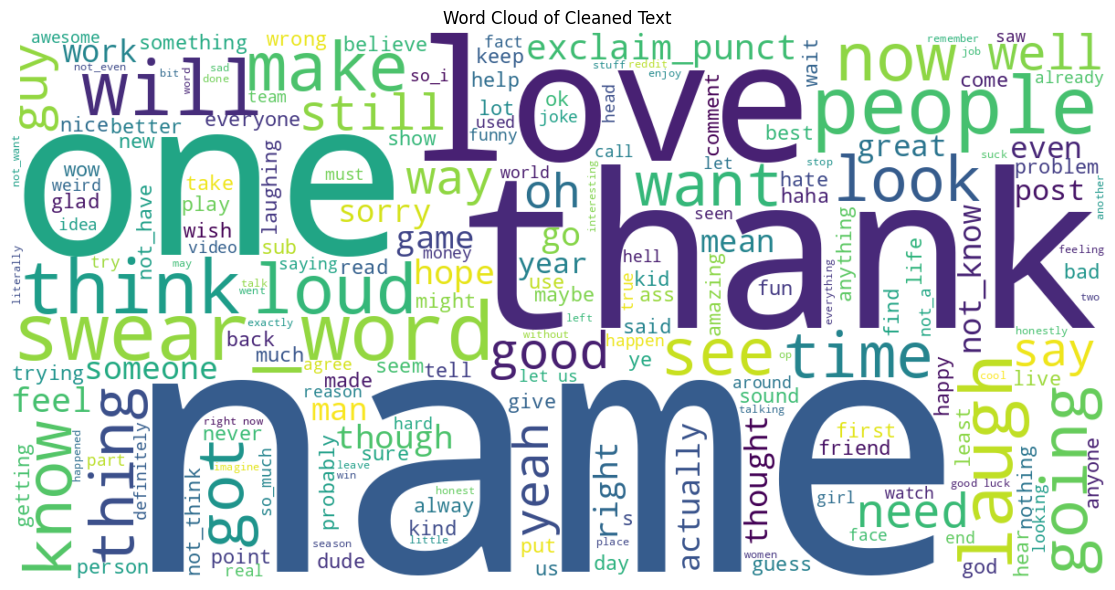

In [ ]:
#plotting WordCloud
from wordcloud import WordCloud

all_text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Text")
plt.tight_layout()
plt.show()



In [ ]:
#splitting the dataset into train or test split
x=df['clean_text']
y=df['label']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(
    x,y,
    test_size=0.2,  #80% for train, 20% for test
    random_state=42, #reproducible
    stratify=y # keeps emotions distribution balanced
)

print('training samples:', len(x_train))
print('testing samples:', len(x_test))

training samples: 166251
testing samples: 41563


In [ ]:
#customising the stopwords
nlp=spacy.load('en_core_web_sm')

stopwords_spacy=nlp.Defaults.stop_words
print(stopwords_spacy)
print(len(stopwords_spacy))


{'other', 'yours', 'each', 'across', 'i', 'thereby', 'all', 'is', '’re', 'should', 'toward', 'give', 'together', 'whereas', 'nor', 'been', '’s', 'one', 'us', "'ll", 'him', 'formerly', 'whence', 'here', 'so', 'what', 'at', 'most', 'thereupon', 'ourselves', '‘m', 'in', 'become', 'therefore', 'front', 'itself', 'else', 'perhaps', 'just', 'everywhere', 'the', 'a', 'thence', 'thru', 'himself', 'though', 'make', 'full', 'put', 'three', 'our', 'whether', 'there', 'since', 'some', "n't", 'when', 'may', 'from', 'will', 'first', 'how', 'alone', 'every', 'neither', 'are', 'ours', 'had', 'which', 'would', 'eight', 'sixty', '’ll', 'really', 'onto', 'against', 'they', 'he', 'eleven', 'meanwhile', 'among', 'yourself', 'unless', 'were', "'d", 'beside', 'anything', 'otherwise', 'already', 'amongst', 'could', 'n‘t', 'either', 'hereafter', 'except', 'wherever', 'whose', 'hundred', 'done', 'via', 'why', 'me', 'before', 'anyone', 'further', '’m', 'once', "'m", 'this', 'namely', 'none', 'noone', 'elsewhere'

In [ ]:
#selecting project specifc words
keep_words= {
    "no", "not", "never", "none", "nothing",  "neither", "without",
    "very", "really", "too", "so", "soo", "extremely","whole",
    "could", "would", "should", "might", "must", "need","serious",
      "now", "still", "already", "yet", "ever"}

custom_stopwords=set(ENGLISH_STOP_WORDS)-keep_words

data_stopwords={"url","user"}
custom_stopwords=custom_stopwords.union(data_stopwords)

custom_stopwords=list(custom_stopwords)
print("Total stopwords:", len(custom_stopwords))
print(custom_stopwords)


Total stopwords: 298
['other', 'yours', 'each', 'while', 'down', 'across', 'becomes', 'anyway', 'i', 'thereby', 'whom', 'eg', 'couldnt', 'call', 'by', 'next', 'all', 'is', 'third', 'toward', 'give', 'together', 'on', 'who', 'whereas', 'nor', 'been', 'or', 'one', 'us', 'whither', 'same', 'him', 'formerly', 'although', 'mostly', 'whereafter', 'whence', 'here', 'almost', 'what', 'cry', 'at', 'whereupon', 'anyhow', 'due', 'system', 'until', 'most', 'latterly', 'for', 'something', 'thereupon', 'always', 'few', 'four', 'out', 'ourselves', 'find', 'both', 'in', 'back', 'such', 'become', 'thus', 'someone', 'therefore', 'nevertheless', 'front', 'user', 'an', 'itself', 'my', 'more', 'your', 'else', 'perhaps', 'to', 'everywhere', 'whereby', 'behind', 'seem', 'above', 'the', 'side', 'a', 'thence', 'thru', 'himself', 'ie', 'it', 'during', 'though', 'less', 'also', 'full', 'enough', 'put', 'own', 'these', 'top', 'amoungst', 'wherein', 'everything', 'three', 'can', 'beyond', 'our', 'whether', 'there'

In [ ]:
#building TF-IDF + logistic regression pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


model=Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=False,
        stop_words=custom_stopwords,
        max_features=60000,
        ngram_range=(1,2), #unigrams +bigrams
        min_df=5,
    )),

    ('logreg' , LogisticRegression(
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced',
        n_jobs=-1
    ))

])

In [ ]:
#training the model
model.fit(x_train, y_train)
print('model training completed')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


model training completed


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# using the same settings as used in the model building
tfidf_eda = TfidfVectorizer(
    lowercase=False,
    stop_words=custom_stopwords,
    max_features=60000,
    ngram_range=(1, 2),
    min_df=5
)

# fit on the cleaned text
tfidf_matrix = tfidf_eda.fit_transform(df['clean_text'])
feature_names = tfidf_eda.get_feature_names_out()


In [ ]:
import numpy as np

def top_tfidf_words_for_label(label, n=15):
    # subset rows for that label
    subset = df[df['label'] == label]

    # transform their text with the same TF-IDF
    mat = tfidf_eda.transform(subset['clean_text'])

    # average TF-IDF score for each feature across this label
    mean_tfidf = mat.mean(axis=0).A1

    # indices of top n features
    top_idx = np.argsort(mean_tfidf)[::-1][:n]

    # map indices back to words
    return [feature_names[i] for i in top_idx]


In [ ]:
labels= ['sadness', 'joy', 'anger', 'gratitude', 'amusement', 'neutral']
row=[]

for label in labels:
    top_words = top_tfidf_words_for_label(label, n=10)
    row.append({
        "Emotion": label.capitalize(),
        "Top TF-IDF features": ", ".join(top_words)
    })

tfidf_table = pd.DataFrame(row)

tfidf_table


,Emotion,Top TF-IDF features
0,Sadness,"sad, sorry, miss, sadly, just, bad, feel, so_s..."
1,Joy,"happy, glad, enjoy, love, fun, like, day, good..."
2,Anger,"swear_word, hate, just, people, hell, no, stup..."
3,Gratitude,"thank, thanks, good, welcome, so_much, thank s..."
4,Amusement,"laugh, loud, laugh loud, haha, funny, laughing..."
5,Neutral,"just, like, would, no, did, people, now, excla..."


In [ ]:
#prediction
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

y_pred=model.predict(x_test)

#accuracy
acc_29=accuracy_score(y_test,y_pred)
macro_f1_29 = f1_score(y_test, y_pred, average="macro")

print(f'test accuracy:{acc_29:.4f}\n')
print(f"29-class Macro F1: {macro_f1_29:.4f}\n")

#detailed per-class metrics
print (classification_report(y_test,y_pred))

test accuracy:0.3289

29-class Macro F1: 0.2847

                precision    recall  f1-score   support

    admiration       0.56      0.48      0.52      3426
     amusement       0.55      0.67      0.60      1772
         anger       0.32      0.40      0.35      1591
     annoyance       0.22      0.10      0.14      2386
      approval       0.30      0.16      0.21      3106
        caring       0.21      0.30      0.25      1029
     confusion       0.24      0.30      0.27      1320
     curiosity       0.26      0.24      0.25      1541
        desire       0.20      0.43      0.27       600
disappointment       0.19      0.14      0.16      1354
   disapproval       0.22      0.26      0.24      1784
       disgust       0.18      0.32      0.23       684
 embarrassment       0.14      0.33      0.19       344
    excitement       0.19      0.27      0.22       875
          fear       0.27      0.51      0.35       503
     gratitude       0.69      0.75      0.72      168

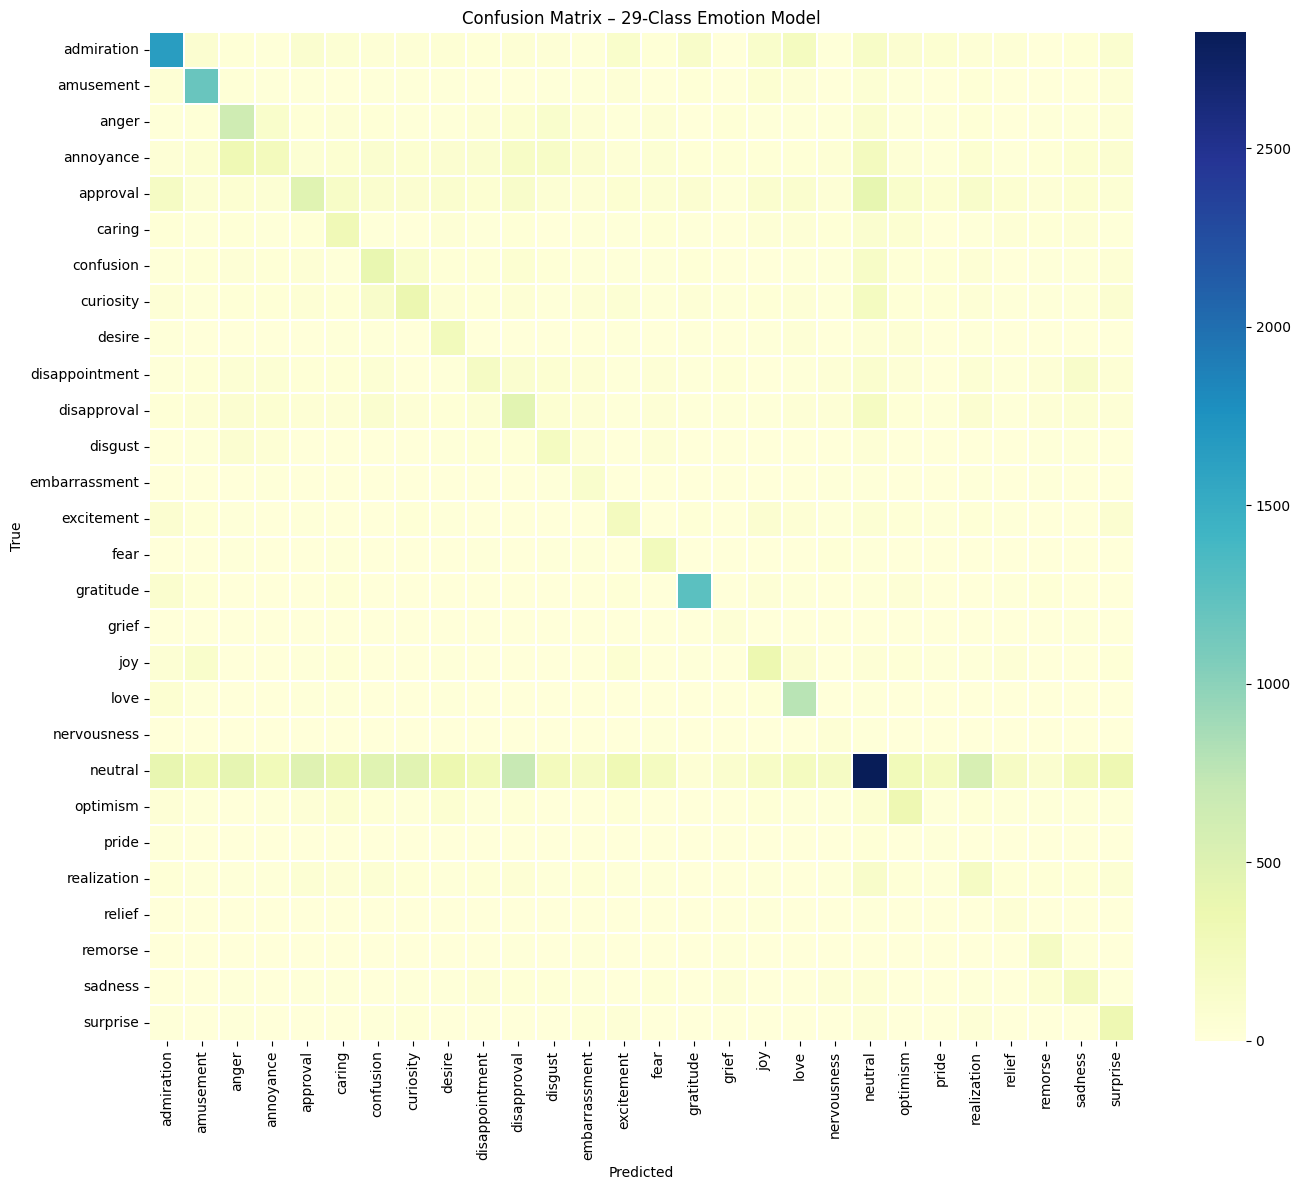

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels_29 = sorted(df['label'].unique())
cm_29 = confusion_matrix(y_test, y_pred, labels=labels_29)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_29,
    xticklabels=labels_29,
    yticklabels=labels_29,
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white"
)
plt.title("Confusion Matrix – 29-Class Emotion Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


#another approach

In [ ]:
positive= {'admiration', 'amusement', 'caring', 'desire', 'excitement',
    'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief', 'surprise'}

negative = {
    'anger', 'annoyance', 'disappointment', 'disapproval', 'disgust',
    'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness'
}

neutral = {
    'neutral', 'confusion', 'curiosity', 'realization'
}

In [ ]:
def map_sentiment (label):
  if label in positive:
    return 'positive'
  elif label in negative:
    return 'negative'
  else:
    return 'neutral'

df['sentiment_class']=df['label'].apply(map_sentiment)
df['sentiment_class'].value_counts

<bound method IndexOpsMixin.value_counts of 0         negative
2          neutral
3         positive
4          neutral
5         positive
            ...   
211219    positive
211220    positive
211221    positive
211222    positive
211223    negative
Name: sentiment_class, Length: 207814, dtype: object>

/tmp/ipython-input-2535760047.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


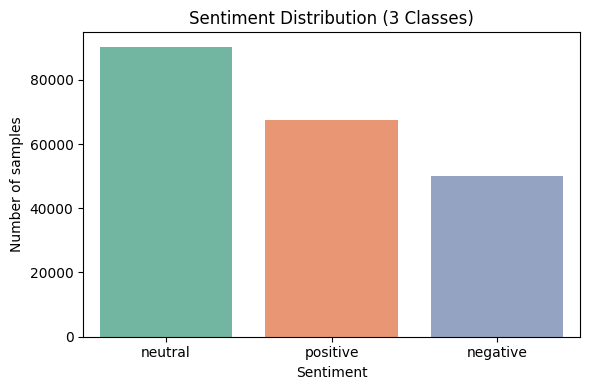

Sentiment percentage distribution (%):
sentiment_class
neutral     43.43
positive    32.42
negative    24.14
Name: count, dtype: float64


In [ ]:
# three sentiment class distribution
sent_counts=df['sentiment_class'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(
    x=sent_counts.index,
    y=sent_counts.values,
    palette="Set2"
)
plt.title("Sentiment Distribution (3 Classes)")
plt.xlabel("Sentiment")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

print("Sentiment percentage distribution (%):")
print((sent_counts / sent_counts.sum() * 100).round(2))


In [ ]:
x=df['clean_text']
y_sent=df['sentiment_class']

x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(
    x, y_sent,
    test_size=0.2,
    random_state=42,
    stratify=y_sent
)

print("Training samples (sentiment):", len(x_train_s))
print("Testing samples (sentiment):", len(x_test_s))


Training samples (sentiment): 166251
Testing samples (sentiment): 41563


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

sentiment_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=False,
        stop_words=custom_stopwords,
        max_features=80000,
        ngram_range=(1, 2),
        min_df=5,
        sublinear_tf=True
    )),
    ('logreg', LogisticRegression(
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        multi_class='multinomial',
        n_jobs=-1
    ))
])

sentiment_model.fit(x_train_s, y_train_s)
print("Sentiment model trained.")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Sentiment model trained.


In [ ]:
#evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_s = sentiment_model.predict(x_test_s)

acc_3 = accuracy_score(y_test_s, y_pred_s)
macro_f1_3 = f1_score(y_test_s, y_pred_s, average="macro")

print(f"Sentiment test accuracy: {acc_3:.4f}\n")
print(f"3-class Macro F1: {macro_f1_3:.4f}\n")

print(classification_report(y_test_s, y_pred_s))


Sentiment test accuracy: 0.6503

3-class Macro F1: 0.6474

              precision    recall  f1-score   support

    negative       0.55      0.65      0.59     10035
     neutral       0.68      0.61      0.64     18052
    positive       0.71      0.70      0.71     13476

    accuracy                           0.65     41563
   macro avg       0.64      0.65      0.65     41563
weighted avg       0.66      0.65      0.65     41563



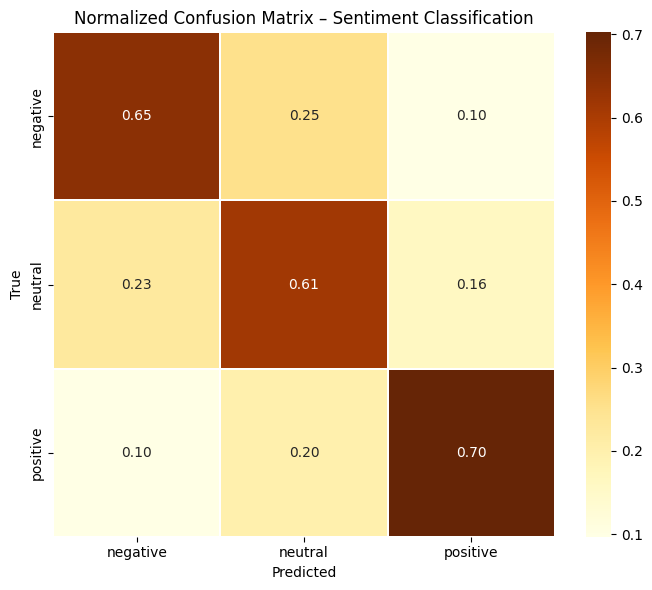

In [ ]:
#Confusion matrix (3-class counts + normalized)
cm_norm = confusion_matrix(y_test_s, y_pred_s, labels=['negative','neutral','positive'], normalize='true')

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='YlOrBr',
    xticklabels=['negative','neutral','positive'],
    yticklabels=['negative','neutral','positive'],
    linewidths=0.3,
    linecolor='white'
)

plt.title('Normalized Confusion Matrix – Sentiment Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Emotion (29-class)", "Sentiment (3-class)"],
    "Accuracy": [acc_29, acc_3],
    "Macro F1": [macro_f1_29, macro_f1_3]
})

comparison


,Model,Accuracy,Macro F1
0,Emotion (29-class),0.328946,0.284707
1,Sentiment (3-class),0.650290,0.647357
